# Case study E7: factor-graph least squares (SymForce)

SymForce (Martiros et al., RSS 2022) generates C++ for robotics least-squares problems from symbolic
Python. Its Table IV times a robot 3D localization problem (5 poses, 20 landmarks) in two variants:

- **dynamic**: one generated function per factor type, assembled by SymForce's optimizer at run time;
- **fixed**: the whole problem's linearization as one flattened generated function, sparsity included.

Scaly writes the same problem, and SymForce's Levenberg-Marquardt, as one generated C function: each
factor type linearized in a `vmap` body by AD, the Gauss-Newton Hessian assembled on its fixed sparsity
pattern, and the damped step solved by the generated sparse `L D L'` inside a `while_loop`. This notebook
builds it, checks that it takes SymForce's iterates, and shows the recorded timings, including a sweep
of problem sizes, where SymForce's flattened code has to grow with the graph.

The Scaly cells run without SymForce. The SymForce side needs `baseline/setup.sh` and is off by default
(`RUN_BASELINES`). The write-up is `internal/notes/case_study_e7_report.html`.

In [1]:
import json
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

HERE = Path.cwd()
sys.path[:0] = [str(HERE), str(HERE.parents[1] / "notebooks")]

import plotstyle
from scaly.codegen import render_c_module

import scaly_impl as si

plotstyle.use()
RUN_BASELINES = False  # True reruns compare.py: SymForce built twice, regenerated per size up to 1000 poses (about an hour)
RESULTS = HERE / "results"

## The problem

Five poses of a robot in SO(3) x R^3 are estimated from matching factors (each pose measures each of
20 known landmarks in its body frame, sigma 0.1) and odometry factors between consecutive poses
(relative pose, sigmas 0.05 rad and 0.2 m). The data are SymForce's own (`gen/measurements.cc`, drawn
by its example with seed 42), stored in `results/robot_3d_localization.json`. Every convention is
SymForce's: quaternions `[x, y, z, w]`, the retraction `R <- R Exp(dR)`, `t <- t + dt`, `Exp` and `Log`
with its epsilon.

In [2]:
p = si.load(RESULTS / "robot_3d_localization.json")
print(
  f"{p.n_poses} poses, {p.n_landmarks} landmarks: {p.n_poses * p.n_landmarks} matching and {p.n_poses - 1} odometry factors, "
  f"{3 * p.n_poses * p.n_landmarks + 6 * (p.n_poses - 1)} residuals, {6 * p.n_poses} unknowns"
)

5 poses, 20 landmarks: 100 matching and 4 odometry factors, 324 residuals, 30 unknowns


## SymForce's solver, generated

`lm_function` is SymForce's `LevenbergMarquardtSolver` with the example's parameters: lambda from 1e4,
halved on an accepted step and quadrupled on a refused one, unit damping, a step accepted on any
decrease, the loop stopped when the relative reduction falls in (-1e-7, 1e-6). Each matching factor's
Jacobian is `sc.jacobian` of its residual in the pose's tangent offset, at zero; the grouped form
evaluates a pose's 20 matching factors in one body, so the pose's rotation is formed once.

In [3]:
X0 = si.identity_poses(p.n_poses)
t0 = time.perf_counter()
lm = si.lm_function(p, name="nb")
X, err, iters, trace_err, trace_lam, trace_acc = lm(X0)
print(f"build and first solve {time.perf_counter() - t0:.1f} s: {int(iters)} iterations, final error {float(err):.10f}")
samples = []
for _ in range(200):
  t = time.perf_counter()
  lm(X0)
  samples.append(time.perf_counter() - t)
print(f"a solve through the Python call: {1e6 * min(samples):.1f} us")

build and first solve 1.0 s: 11 iterations, final error 132.3573192235
a solve through the Python call: 54.7 us


SymForce's own run of the same problem (its fixed variant, `baseline/bench_symforce.cc`) takes 11
iterations to an error of 132.35731922346. The recorded comparison of every iteration:

In [4]:
sweep = json.loads((RESULTS / "sweep.json").read_text())
ref = sweep["paper"]["symforce_no_timers"]["fixed"]["trace"][1:]
print(f"{'it':>3s} {'lambda SymForce':>16s} {'lambda Scaly':>13s} {'error SymForce':>18s} {'error Scaly':>18s}")
for k, t in enumerate(ref):
  print(f"{k:3d} {t['lambda']:16.6g} {trace_lam[k]:13.6g} {t['new_error']:18.10f} {trace_err[k]:18.10f}")
print("largest pose difference at the solution:", np.abs(np.asarray(X) - np.array(sweep["paper"]["symforce_no_timers"]["fixed"]["poses"])).max())

 it  lambda SymForce  lambda Scaly     error SymForce        error Scaly
  0            10000         10000  295410.8302784733  295410.8302784733
  1             5000          5000  176768.5956007824  176768.5956007825
  2             2500          2500  107970.6591454079  107970.6591454077
  3             1250          1250   57172.5705950416   57172.5705950411
  4              625           625   21946.3899113057   21946.3899113053
  5            312.5         312.5    5382.4981484904    5382.4981484901
  6           156.25        156.25     466.5298981221     466.5298981220
  7           78.125        78.125     133.4759203707     133.4759203707
  8          39.0625       39.0625     132.3577396173     132.3577396173
  9          19.5312       19.5312     132.3573193125     132.3573193125
 10          9.76562       9.76562     132.3573192235     132.3573192235
largest pose difference at the solution: 2.858824288409778e-15


The generated C, and what one `vmap` body per factor type means for its size:

In [5]:
module = render_c_module(lm)
print(f"{len(module.body.encode()) / 1e3:.0f} kB of C")

132 kB of C


## Table IV

`compare.py` times SymForce's variants with the calls its benchmark times (`Relinearize` for linearize,
`Optimize(values, 1)` repeated on the same values for iterate) and the whole solve from the initial
values; SymForce is built as released (its internal timers on) and with the timers compiled out.
Scaly's three Functions are timed from C.

In [6]:
if RUN_BASELINES:
  subprocess.run([sys.executable, str(HERE / "compare.py"), "--out", str(RESULTS / "sweep.json")], check=True)
  sweep = json.loads((RESULTS / "sweep.json").read_text())
pp = sweep["paper"]
rows = [
  ("SymForce dynamic (as released)", pp["symforce_released"]["dynamic"]),
  ("SymForce fixed (as released)", pp["symforce_released"]["fixed"]),
  ("SymForce dynamic (timers off)", pp["symforce_no_timers"]["dynamic"]),
  ("SymForce fixed (timers off)", pp["symforce_no_timers"]["fixed"]),
]
print(f"{'':32s} {'linearize us':>13s} {'iterate us':>11s} {'solve us':>9s}")
for name, r in rows:
  print(f"{name:32s} {r['linearize_us']:13.2f} {r['iterate_us']:11.2f} {r['solve_us']:9.1f}")
for name, key in (("Scaly, factors grouped by pose", "scaly"), ("Scaly, one body per factor", "scaly_per_factor")):
  r = pp[key]
  print(f"{name:32s} {r['linearize']['best_us']:13.2f} {r['iterate']['best_us']:11.2f} {r['solve']['best_us']:9.1f}")

                                  linearize us  iterate us  solve us
SymForce dynamic (as released)            7.08       20.74     140.1
SymForce fixed (as released)              2.42       10.50      75.1
SymForce dynamic (timers off)             6.93       18.95     126.8
SymForce fixed (timers off)               2.29        8.94      64.5
Scaly, factors grouped by pose            3.40        7.85      51.9
Scaly, one body per factor                4.27       12.15      77.2


## Growing the graph

For each size, SymForce's own generator regenerates the example (`gen_symforce.py`), with its fixed
variant while one generation fits the budget, and the same data go to Scaly.

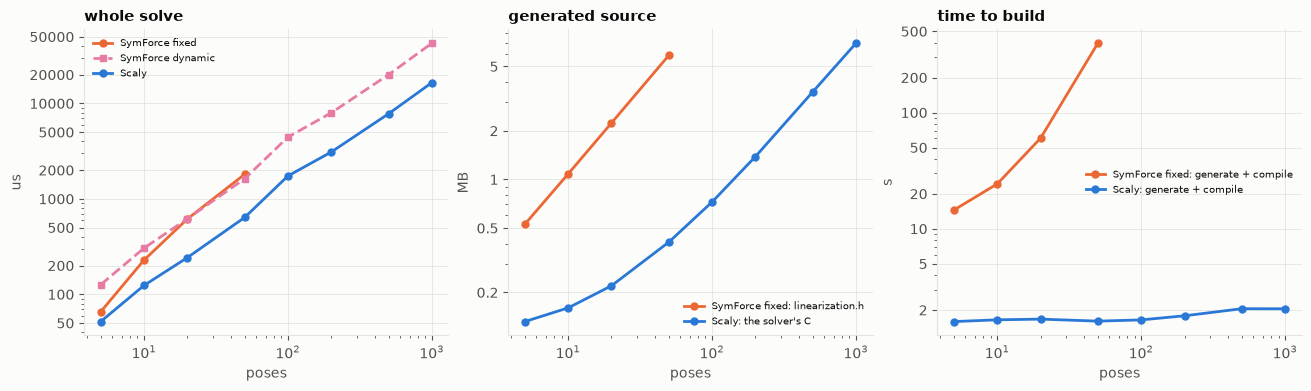

In [7]:
sw = sorted(sweep["sweep"], key=lambda r: r["n_poses"])
n = np.array([r["n_poses"] for r in sw])
fixed = np.array([r["symforce"]["fixed"]["solve_us"] if "fixed" in r["symforce"] else np.nan for r in sw])
dyn = np.array([r["symforce"]["dynamic"]["solve_us"] for r in sw])
scaly = np.array([r["scaly"]["solve"]["best_us"] for r in sw])
gen_s = np.array([r["symforce_generate"]["t_generate"] if "fixed" in r["symforce"] else np.nan for r in sw])
compile_s = np.array([r["symforce_compile_s"] if "fixed" in r["symforce"] else np.nan for r in sw])
lin_mb = np.array([r["symforce_generate"]["linearization_bytes"] / 1e6 if "fixed" in r["symforce"] else np.nan for r in sw])
scaly_mb = np.array([r["scaly"]["solve"]["c_bytes"] / 1e6 for r in sw])
scaly_build = np.array([r["scaly"]["solve"]["t_generate"] + r["scaly"]["solve"]["t_compile"] for r in sw])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].loglog(n, fixed, "o-", color="C1", label="SymForce fixed")
axes[0].loglog(n, dyn, "s--", color="C4", label="SymForce dynamic")
axes[0].loglog(n, scaly, "o-", color="C0", label="Scaly")
axes[0].set_title("whole solve")
axes[0].set_ylabel("us")
axes[1].loglog(n, lin_mb, "o-", color="C1", label="SymForce fixed: linearization.h")
axes[1].loglog(n, scaly_mb, "o-", color="C0", label="Scaly: the solver's C")
axes[1].set_title("generated source")
axes[1].set_ylabel("MB")
axes[2].loglog(n, gen_s + compile_s, "o-", color="C1", label="SymForce fixed: generate + compile")
axes[2].loglog(n, scaly_build, "o-", color="C0", label="Scaly: generate + compile")
axes[2].set_title("time to build")
axes[2].set_ylabel("s")
for ax in axes:
  ax.set_xlabel("poses")
  ax.yaxis.set_major_locator(mticker.LogLocator(subs=(1, 2, 5)))
  ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
  ax.yaxis.set_minor_formatter(mticker.NullFormatter())
  ax.legend(frameon=False, fontsize=7)
plt.show()

In [8]:
print(f"{'poses':>6s} {'fixed us':>10s} {'dynamic us':>11s} {'Scaly us':>9s} {'iterations':>10s} {'same iterates':>13s}")
for r in sw:
  s = r["symforce"]
  vs = r["scaly"].get("vs_symforce", {})
  same = vs.get("iterations_equal") and vs.get("lambda_equal") and vs.get("accepted_equal")
  fx = s["fixed"]["solve_us"] if "fixed" in s else float("nan")
  print(
    f"{r['n_poses']:6d} {fx:10.1f} {s['dynamic']['solve_us']:11.1f} {r['scaly']['solve']['best_us']:9.1f} {r['scaly']['solve']['iterations']:10d} {str(same):>13s}"
  )

 poses   fixed us  dynamic us  Scaly us iterations same iterates
     5       65.7       126.3      51.8         11          True
    10      228.7       305.3     124.0         13          True
    20      616.2       618.0     242.7         13          True
    50     1809.2      1626.0     639.0         13          True
   100        nan      4439.9    1739.0         18          True
   200        nan      7977.4    3099.0         16          True
   500        nan     20014.8    7794.0         16          True
  1000        nan     42763.0   16529.0         17          True


## Findings

- **The same algorithm, the same iterates.** Scaly's generated LM takes SymForce's iterations with the
  same lambda and acceptance at every step, at every size from 5 to 1000 poses, errors to 1e-12 and
  poses to 1e-14.
- **At Table IV's size Scaly is faster where the plan asked**: one iteration 7.8 against SymForce
  fixed's 8.9 us (timers off), the whole solve 52 against 64 us; linearizing alone it is slower (3.4
  against 2.3 us), since the flattened function shares subexpressions across the whole problem.
- **The gap widens with the graph**: 2.5x the faster SymForce variant from 20 poses on. SymForce's
  flattened code stops paying at 20 poses and cannot be generated within 20 minutes at 100.
- **No compile blow-up**: Scaly builds every size in about 2 s; its C grows only by the fixed pattern's
  index tables.